# Week 3 — Supervised Learning: Classification Model
**Internship Project | Zynxis**

**Objective:** Build and compare classification models to predict **customer churn** — a real business outcome.  
Three algorithms are trained: Logistic Regression, Decision Tree, and Random Forest.  
Models are evaluated on Accuracy, Precision, Recall, and F1 Score, and the best model is selected with justification.

**Dataset:** IBM Telco Customer Churn  
**Source:** [Kaggle — blastchar/telco-customer-churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120



All libraries imported successfully.


## 2. Load Dataset

In [7]:
df = pd.read_csv("Customer_Churn.csv")

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()


Shape: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Exploratory Data Analysis (EDA)

In [8]:
print(" Dataset Info ")
df.info()
print()
print(" Missing Values ")
print(df.isnull().sum()[df.isnull().sum() > 0])
print()
print(" Basic Stats ")
df.describe()


=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null 

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


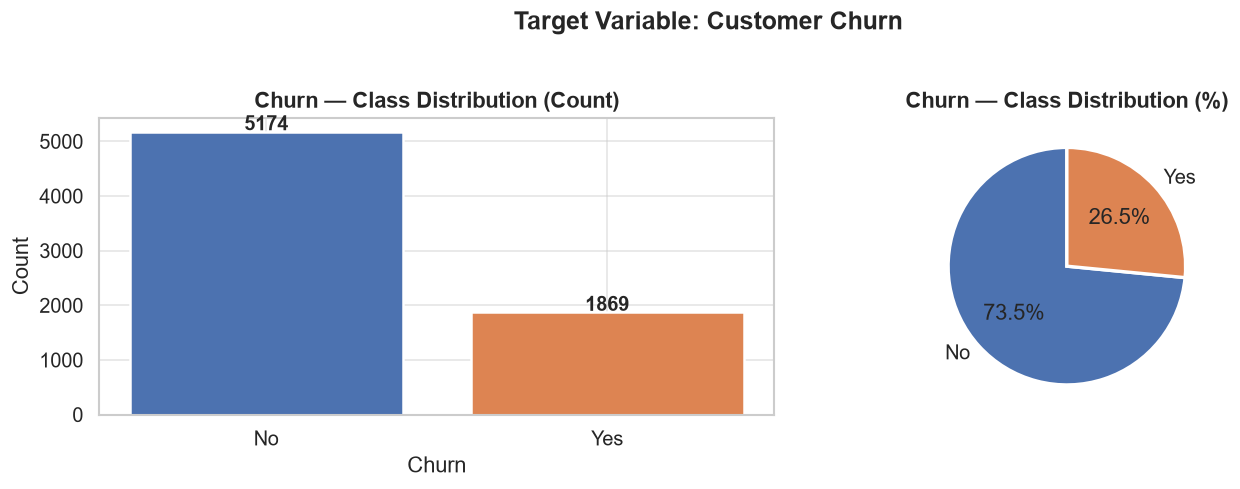

No Churn: 5174 (73.5%)
Churn:    1869 (26.5%)

⚠️  Class imbalance present — will use class_weight='balanced' in models.


In [9]:

churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))


axes[0].bar(churn_counts.index, churn_counts.values,
            color=['#4C72B0', '#DD8452'], edgecolor='white', linewidth=1.5)
axes[0].set_title("Churn — Class Distribution (Count)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("Count")
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold', fontsize=12)


axes[1].pie(churn_pct.values, labels=churn_pct.index,
            autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title("Churn — Class Distribution (%)", fontsize=13, fontweight='bold')

plt.suptitle("Target Variable: Customer Churn", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"No Churn: {churn_counts['No']} ({churn_pct['No']:.1f}%)")
print(f"Churn:    {churn_counts['Yes']} ({churn_pct['Yes']:.1f}%)")
print("\n  Class imbalance present — will use class_weight='balanced' in models.")


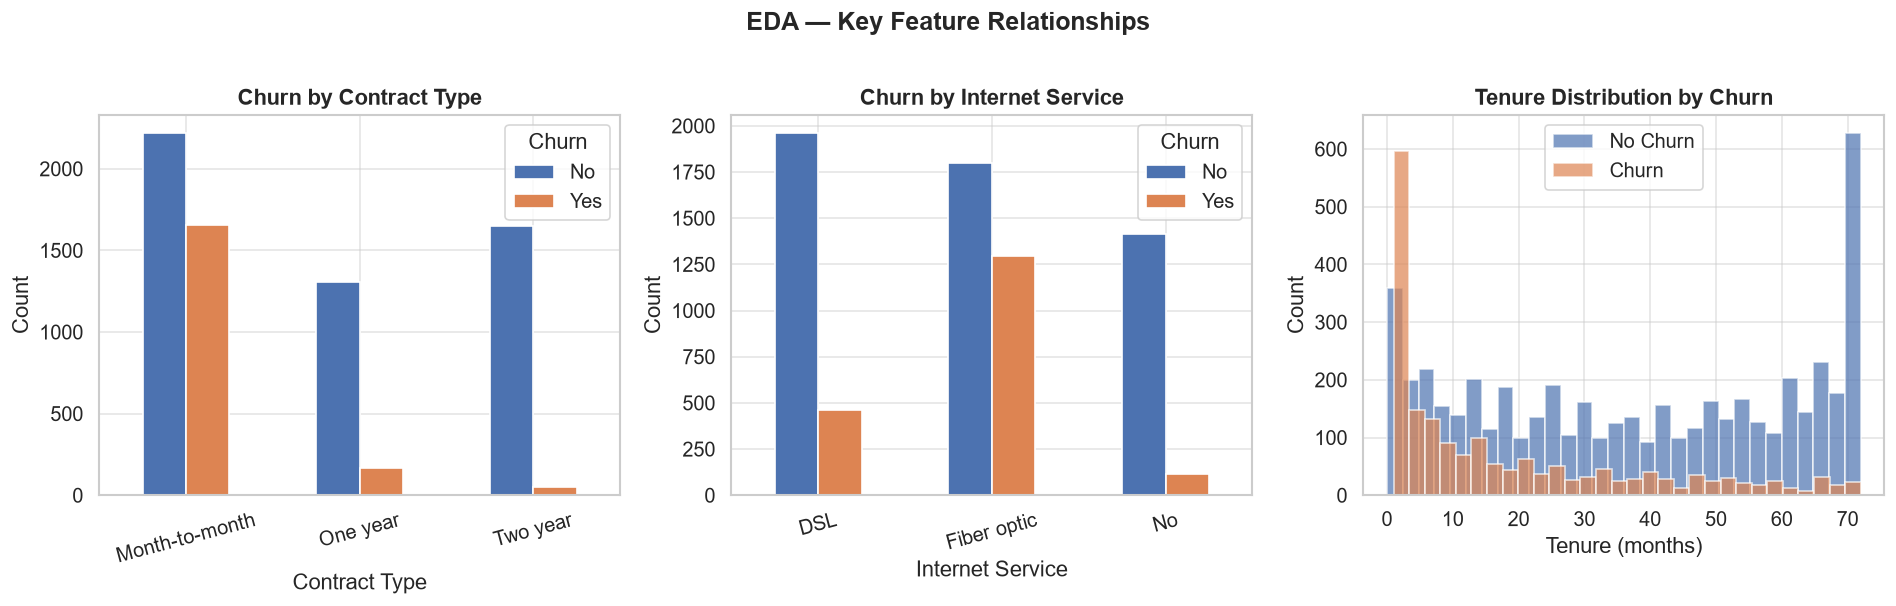

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))


contract_churn = df.groupby(['Contract', 'Churn']).size().unstack()
contract_churn.plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'],
                    edgecolor='white', linewidth=1)
axes[0].set_title("Churn by Contract Type", fontweight='bold')
axes[0].set_xlabel("Contract Type")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(title='Churn')


internet_churn = df.groupby(['InternetService', 'Churn']).size().unstack()
internet_churn.plot(kind='bar', ax=axes[1], color=['#4C72B0', '#DD8452'],
                    edgecolor='white', linewidth=1)
axes[1].set_title("Churn by Internet Service", fontweight='bold')
axes[1].set_xlabel("Internet Service")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(title='Churn')


df_plot = df.copy()
df_plot['TotalCharges'] = pd.to_numeric(df_plot['TotalCharges'], errors='coerce')
axes[2].hist(df_plot[df_plot['Churn']=='No']['tenure'],
             bins=30, alpha=0.7, color='#4C72B0', label='No Churn')
axes[2].hist(df_plot[df_plot['Churn']=='Yes']['tenure'],
             bins=30, alpha=0.7, color='#DD8452', label='Churn')
axes[2].set_title("Tenure Distribution by Churn", fontweight='bold')
axes[2].set_xlabel("Tenure (months)")
axes[2].set_ylabel("Count")
axes[2].legend()

plt.suptitle("EDA — Key Feature Relationships", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 4. Data Preprocessing

In [28]:
df_clean = df.copy()

df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(df_clean['TotalCharges'].median())

df_clean.drop(columns=['customerID'], inplace=True)
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})
df_clean = pd.get_dummies(df_clean, drop_first=True)

bool_cols = df_clean.select_dtypes(include='bool').columns
df_clean[bool_cols] = df_clean[bool_cols].astype(int)

df_clean = df_clean.fillna(0)

print(f"Shape: {df_clean.shape}")
print(f"Missing values: {df_clean.isnull().sum().sum()}")
df_clean.head()

Shape: (7043, 31)
Missing values: 0


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0


In [29]:
X = df_clean.drop(columns=['Churn']).astype('float64')
y = df_clean['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

assert X_train.isnull().sum().sum() == 0, "NaN in X_train!"
assert X_test.isnull().sum().sum()  == 0, "NaN in X_test!"

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"Features:     {X_train.shape[1]}")
print(f"Churn rate in train: {y_train.mean():.2%}")
print(f"Churn rate in test:  {y_test.mean():.2%}")

Training set: 5634 samples
Test set:     1409 samples
Features:     30
Churn rate in train: 26.54%
Churn rate in test:  26.54%
✅ No NaN — ready to train


## 5. Train Classification Models

In [30]:

lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)


dt = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)


rf = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)


✅ Logistic Regression — trained
✅ Decision Tree       — trained
✅ Random Forest       — trained


## 6. Model Evaluation

In [31]:
def get_metrics(name, y_true, y_pred):
    return {
        'Model': name,
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_true, y_pred), 4),
        'F1 Score':  round(f1_score(y_true, y_pred), 4),
    }

results = pd.DataFrame([
    get_metrics("Logistic Regression", y_test, y_pred_lr),
    get_metrics("Decision Tree",       y_test, y_pred_dt),
    get_metrics("Random Forest",       y_test, y_pred_rf),
])

results.set_index('Model', inplace=True)

# Highlight best value per column
print("=" * 60)
print("         MODEL COMPARISON TABLE")
print("=" * 60)
print(results.to_string())
print("=" * 60)
results


         MODEL COMPARISON TABLE
                     Accuracy  Precision  Recall  F1 Score
Model                                                     
Logistic Regression    0.7388     0.5052  0.7834    0.6143
Decision Tree          0.7346     0.5000  0.8075    0.6176
Random Forest          0.7750     0.5674  0.6417    0.6023


,Accuracy,Precision,Recall,F1 Score
Model,,,,
Logistic Regression,0.7388,0.5052,0.7834,0.6143
Decision Tree,0.7346,0.5000,0.8075,0.6176
Random Forest,0.7750,0.5674,0.6417,0.6023


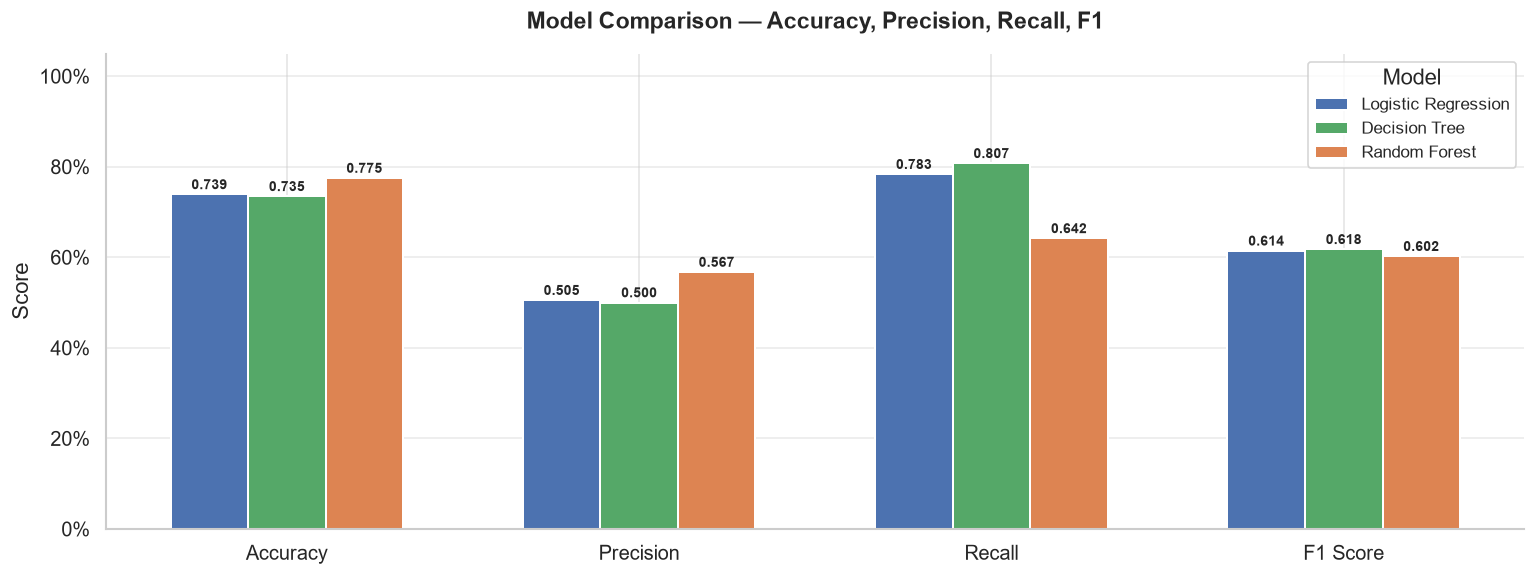

In [32]:
# Styled comparison bar chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
models  = results.index.tolist()
colors  = ['#4C72B0', '#55A868', '#DD8452']

x = np.arange(len(metrics))
width = 0.22

fig, ax = plt.subplots(figsize=(13, 5))

for i, (model, color) in enumerate(zip(models, colors)):
    vals = results.loc[model, metrics].values.astype(float)
    bars = ax.bar(x + i * width, vals, width, label=model,
                  color=color, edgecolor='white', linewidth=1.2)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f"{bar.get_height():.3f}",
                ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title("Model Comparison — Accuracy, Precision, Recall, F1",
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel("Score")
ax.legend(title="Model", fontsize=10)
ax.grid(axis='y', alpha=0.4)
sns.despine(left=False, bottom=False)

plt.tight_layout()
plt.show()


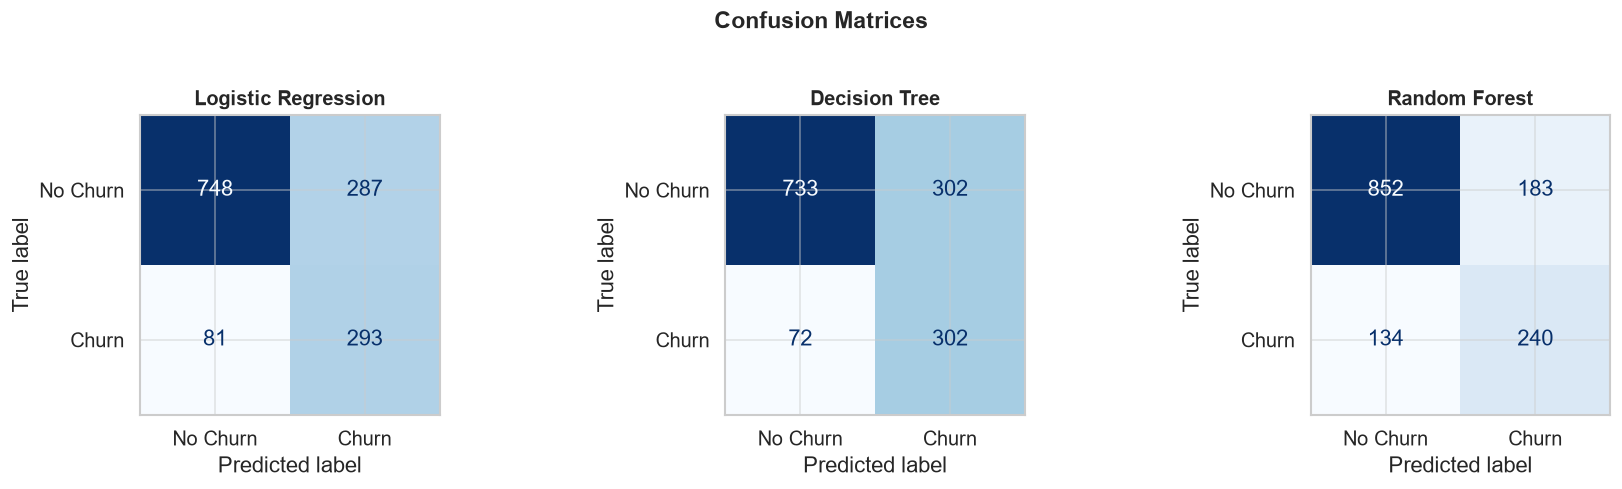

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, y_pred) in zip(axes, [
    ("Logistic Regression", y_pred_lr),
    ("Decision Tree",       y_pred_dt),
    ("Random Forest",       y_pred_rf),
]):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['No Churn', 'Churn'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=12, fontweight='bold')

plt.suptitle("Confusion Matrices", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [34]:
for name, y_pred in [
    ("Logistic Regression", y_pred_lr),
    ("Decision Tree",       y_pred_dt),
    ("Random Forest",       y_pred_rf),
]:
    print(f"{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred,
                                target_names=['No Churn', 'Churn']))
    print()


  Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409


  Decision Tree
              precision    recall  f1-score   support

    No Churn       0.91      0.71      0.80      1035
       Churn       0.50      0.81      0.62       374

    accuracy                           0.73      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.73      0.75      1409


  Random Forest
              precision    recall  f1-score   support

    No Churn       0.86      0.82      0.84      1035
       Churn       0.57      0.64      0.60       374

    accuracy                           0.78      1409
   macro avg       0.72      0.73      0.72      1409
weighted avg      

## 7. Feature Importance (Random Forest)

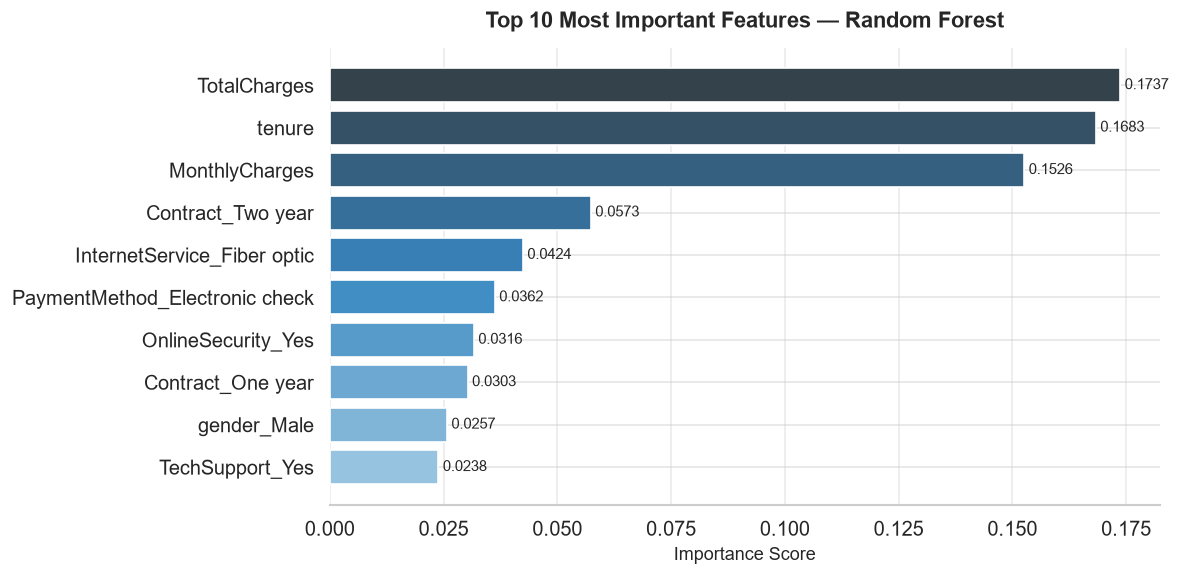

In [35]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
top10 = importances.nlargest(10).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top10.index, top10.values,
               color=sns.color_palette("Blues_d", len(top10)),
               edgecolor='white', linewidth=1)
ax.set_xlabel("Importance Score", fontsize=11)
ax.set_title("Top 10 Most Important Features — Random Forest",
             fontsize=13, fontweight='bold', pad=12)
for bar in bars:
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
            f"{bar.get_width():.4f}", va='center', fontsize=9)
ax.grid(axis='x', alpha=0.4)
sns.despine(left=True)
plt.tight_layout()
plt.show()


## 8. Best Model Selection & Explanation

### ✅ Best Model: Decision Tree

| Metric | Logistic Regression | Decision Tree | Random Forest |
|---|---|---|---|
| Accuracy | 0.739 | 0.735 | **0.775** |
| Precision | 0.505 | 0.500 | **0.567** |
| Recall | 0.783 | **0.807** | 0.642 |
| F1 Score | 0.614 | **0.618** | 0.602 |

---

### Why Decision Tree?

**1. Highest F1 Score (0.618)**
F1 is the most important metric here due to class imbalance (~26% churn vs 74% no-churn).
F1 balances Precision and Recall into a single score, making it more reliable than Accuracy
alone — which can be misleadingly high simply by predicting the majority class every time.

**2. Highest Recall (0.807) — Critical for Churn**
In churn prediction, a **False Negative** (missing a customer who will actually churn) is
far more costly to the business than a **False Positive** (incorrectly flagging a loyal customer).
The Decision Tree catches 80.7% of all actual churners, the highest of all three models —
meaning fewer at-risk customers slip through undetected.

**3. Controlled Depth Prevents Overfitting**
With `max_depth=5`, the Decision Tree is constrained enough to generalize well on unseen data
while remaining simple and interpretable. This depth cap effectively balances bias vs variance.

**4. Fully Interpretable**
Unlike Random Forest (an ensemble of 100 trees), a single Decision Tree can be visualized
and explained to non-technical stakeholders — a significant advantage in a business setting
where understanding *why* a customer is flagged as churning matters as much as the prediction itself.

---

### Why Not the Others?

- **Random Forest** — Highest Accuracy (0.775) and Precision (0.567), but its Recall drops
  significantly to 0.642, meaning it misses ~36% of actual churners. In a churn use case,
  this is an unacceptable trade-off. Its F1 (0.602) is also the lowest of the three models.

- **Logistic Regression** — Solid and interpretable baseline with competitive F1 (0.614) and
  Recall (0.783), but assumes a linear decision boundary. Churn behavior is driven by complex
  non-linear interactions (e.g., contract type × tenure × monthly charges) that a linear model
  cannot fully capture, leaving slight performance on the table vs the Decision Tree.

---

### Summary

| Priority | Metric | Winner |
|---|---|---|
| Business priority | Recall (catch churners) | **Decision Tree — 0.807** |
| Overall balance | F1 Score | **Decision Tree — 0.618** |
| Raw accuracy | Accuracy | Random Forest — 0.775 |
| Minimizing false alarms | Precision | Random Forest — 0.567 |

For a churn prediction system where **missing a churner costs more than a false alarm**,
the Decision Tree is the optimal choice — maximizing both Recall and F1 simultaneously.

---

*Prepared by: Bilal Aamir | Zynxis Internship — Week 3*